Using Device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.65MB/s]



==== EXPERIMENT 1 ====

Epoch [1/10]
Train Loss: 0.4785 | Train Accuracy: 85.42%
Validation Loss: 0.2336 | Validation Accuracy: 92.87%
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.2451 | Train Accuracy: 92.58%
Validation Loss: 0.1888 | Validation Accuracy: 94.30%
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.1964 | Train Accuracy: 93.99%
Validation Loss: 0.1465 | Validation Accuracy: 95.39%
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1731 | Train Accuracy: 94.73%
Validation Loss: 0.1365 | Validation Accuracy: 96.04%
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1532 | Train Accuracy: 95.19%
Validation Loss: 0.1245 | Validation Accuracy: 96.29%
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1413 | Train Accuracy: 95.53%
Validation Loss: 0.1217 | Validation Accuracy: 96.42%
--------------------------------------------------
Epo

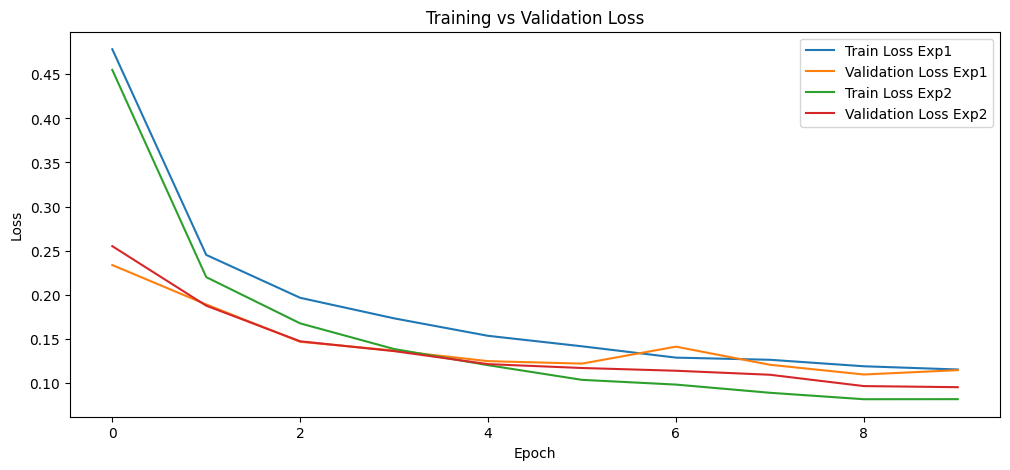

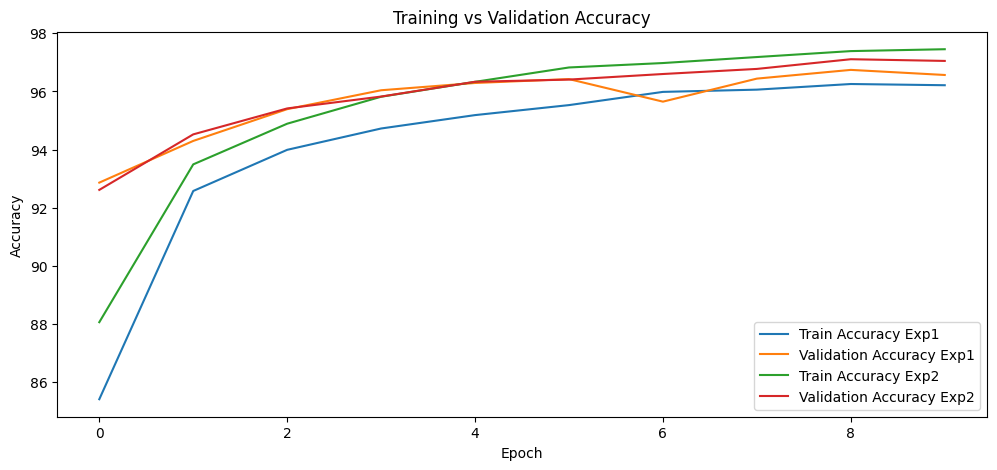

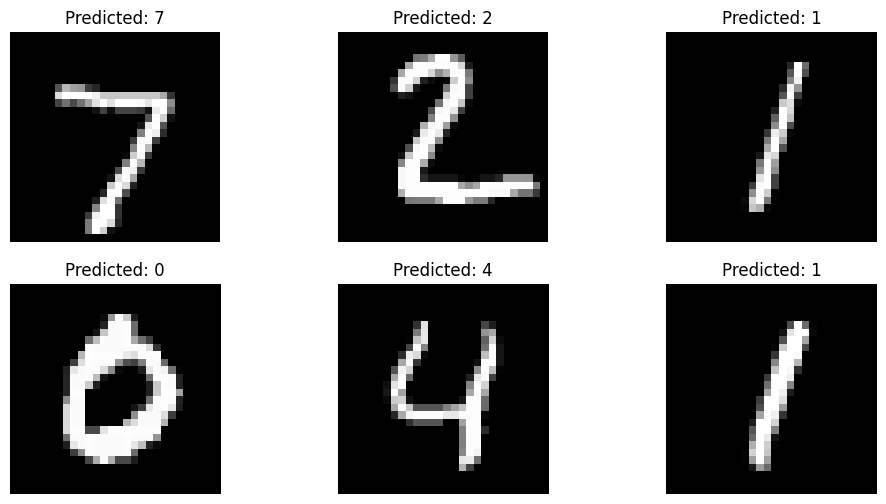

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# 3. Data Preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# 4. Load Dataset

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# 5. Split Dataset
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

# =========================================================
# 6. Data Loaders
# =========================================================

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 7. Define MLP Model
class MLP(nn.Module):

    def __init__(self, hidden_size=128, activation="relu"):
        super(MLP, self).__init__()

        # Select Activation Function
        if activation == "relu":
            act_function = nn.ReLU()

        elif activation == "tanh":
            act_function = nn.Tanh()

        else:
            act_function = nn.ReLU()

        self.model = nn.Sequential(

            # Input Layer
            nn.Flatten(),

            # Hidden Layer 1
            nn.Linear(28 * 28, hidden_size),
            act_function,

            # Optional Regularization
            nn.Dropout(0.2),

            # Hidden Layer 2
            nn.Linear(hidden_size, 64),
            act_function,

            # Output Layer
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)


# 8. Training Function

def train_model(model, optimizer, criterion, epochs=10):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):


        # Training

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward
            outputs = model(images)

            loss = criterion(outputs, labels)

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)


        # Validation

        model.eval()

        val_running_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)


        # Print Results


        print(f"Epoch [{epoch+1}/{epochs}]")

        print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")

        print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}%")

        print("-" * 50)

    return train_losses, val_losses, train_accuracies, val_accuracies


# 9. Experiment 1

print("\n==== EXPERIMENT 1 ====\n")

model1 = MLP(hidden_size=128, activation="relu").to(device)

criterion1 = nn.CrossEntropyLoss()

optimizer1 = optim.Adam(
    model1.parameters(),
    lr=0.001
)

results1 = train_model(
    model1,
    optimizer1,
    criterion1,
    epochs=10
)


# 10. Experiment 2

print("\n==== EXPERIMENT 2 ====\n")

model2 = MLP(hidden_size=256, activation="tanh").to(device)

criterion2 = nn.CrossEntropyLoss()

optimizer2 = optim.Adam(
    model2.parameters(),
    lr=0.0005
)

results2 = train_model(
    model2,
    optimizer2,
    criterion2,
    epochs=10
)


# 11. Evaluation Function

def evaluate_model(model, criterion):

    model.eval()

    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    final_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total

    return final_loss, accuracy


# 12. Evaluate Experiment 1


loss1, acc1 = evaluate_model(model1, criterion1)

print("\n===== Experiment 1 Test Results =====")

print(f"Final Test Loss: {loss1:.4f}")

print(f"Test Accuracy: {acc1:.2f}%")

# 13. Evaluate Experiment 2

loss2, acc2 = evaluate_model(model2, criterion2)

print("\n===== Experiment 2 Test Results =====")

print(f"Final Test Loss: {loss2:.4f}")

print(f"Test Accuracy: {acc2:.2f}%")

# 14. Compare Experiments

print("\n===== Comparison Table =====\n")

print("{:<12} {:<12} {:<15} {:<15} {:<15} {:<15}".format(
    "Experiment",
    "Activation",
    "Hidden Size",
    "Learning Rate",
    "Test Accuracy",
    "Final Loss"
))

print("-" * 90)

print("{:<12} {:<12} {:<15} {:<15} {:<15} {:<15}".format(
    "Exp 1",
    "ReLU",
    "128",
    "0.001",
    f"{acc1:.2f}%",
    f"{loss1:.4f}"
))

print("{:<12} {:<12} {:<15} {:<15} {:<15} {:<15}".format(
    "Exp 2",
    "Tanh",
    "256",
    "0.0005",
    f"{acc2:.2f}%",
    f"{loss2:.4f}"
))

# 15. Visualization

train_losses1, val_losses1, train_acc1, val_acc1 = results1

train_losses2, val_losses2, train_acc2, val_acc2 = results2

# Loss Curves

plt.figure(figsize=(12,5))

plt.plot(train_losses1, label="Train Loss Exp1")
plt.plot(val_losses1, label="Validation Loss Exp1")

plt.plot(train_losses2, label="Train Loss Exp2")
plt.plot(val_losses2, label="Validation Loss Exp2")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Accuracy Curves

plt.figure(figsize=(12,5))

plt.plot(train_acc1, label="Train Accuracy Exp1")
plt.plot(val_acc1, label="Validation Accuracy Exp1")

plt.plot(train_acc2, label="Train Accuracy Exp2")
plt.plot(val_acc2, label="Validation Accuracy Exp2")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# 16. Sample Predictions

model1.eval()

examples = iter(test_loader)
example_data, example_targets = next(examples)

example_data = example_data.to(device)

with torch.no_grad():
    outputs = model1(example_data)

_, predictions = torch.max(outputs, 1)

plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(example_data[i].cpu().squeeze(), cmap="gray")

    plt.title(f"Predicted: {predictions[i].item()}")

    plt.axis("off")

plt.show()